# IMPORTANDO DATOS

In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving datos_tratados.csv to datos_tratados.csv


In [3]:
import pandas as pd

df = pd.read_csv("datos_tratados.csv")
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,MonthlyCharges,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [4]:
df.shape

(7267, 22)

In [5]:
df = df.drop("customerID", axis=1)

In [6]:
df.columns

Index(['Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod', 'MonthlyCharges',
       'account.Charges.Total', 'Cuentas_Diarias'],
      dtype='object')

# Encoding

In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [8]:
df_encoded.head()

,customer.SeniorCitizen,customer.tenure,MonthlyCharges,account.Charges.Total,Cuentas_Diarias,Churn_Yes,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,9,65.6,593.30,2.186667,False,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,1.996667,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,2.463333,True,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,3.266667,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,2.796667,True,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


In [9]:
df_encoded.shape

(7267, 32)

# Verificación de la Proporción de Cancelación (Churn)

In [10]:
conteo = df["Churn"].value_counts()
proporcion = df["Churn"].value_counts(normalize=True)

print("Cantidad de clientes por clase:")
print(conteo)

print("\nProporción de clientes por clase:")
print(proporcion)

Cantidad de clientes por clase:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporción de clientes por clase:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


# Balanceo de Clases

In [12]:
df_encoded.columns

Index(['customer.SeniorCitizen', 'customer.tenure', 'MonthlyCharges',
       'account.Charges.Total', 'Cuentas_Diarias', 'Churn_Yes',
       'customer.gender_Male', 'customer.Partner_Yes',
       'customer.Dependents_Yes', 'phone.PhoneService_Yes',
       'phone.MultipleLines_No phone service', 'phone.MultipleLines_Yes',
       'internet.InternetService_Fiber optic', 'internet.InternetService_No',
       'internet.OnlineSecurity_No internet service',
       'internet.OnlineSecurity_Yes',
       'internet.OnlineBackup_No internet service',
       'internet.OnlineBackup_Yes',
       'internet.DeviceProtection_No internet service',
       'internet.DeviceProtection_Yes',
       'internet.TechSupport_No internet service', 'internet.TechSupport_Yes',
       'internet.StreamingTV_No internet service', 'internet.StreamingTV_Yes',
       'internet.StreamingMovies_No internet service',
       'internet.StreamingMovies_Yes', 'account.Contract_One year',
       'account.Contract_Two year', 'accou

In [13]:
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [15]:
print(X_train.shape)
print(X_test.shape)

(5086, 31)
(2181, 31)


In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Distribución original:")
print(y_train.value_counts())

print("\nDistribución después de SMOTE:")
print(y_train_bal.value_counts())

Distribución original:
Churn_Yes
False    3749
True     1337
Name: count, dtype: int64

Distribución después de SMOTE:
Churn_Yes
False    3749
True     3749
Name: count, dtype: int64


# Normalización o Estandarización

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

print("Datos de entrenamiento escalados:", X_train_scaled.shape)
print("Datos de prueba escalados:", X_test_scaled.shape)

Datos de entrenamiento escalados: (7498, 31)
Datos de prueba escalados: (2181, 31)


# **🎯 Correlación y Selección de Variables**

# Análisis de Correlación

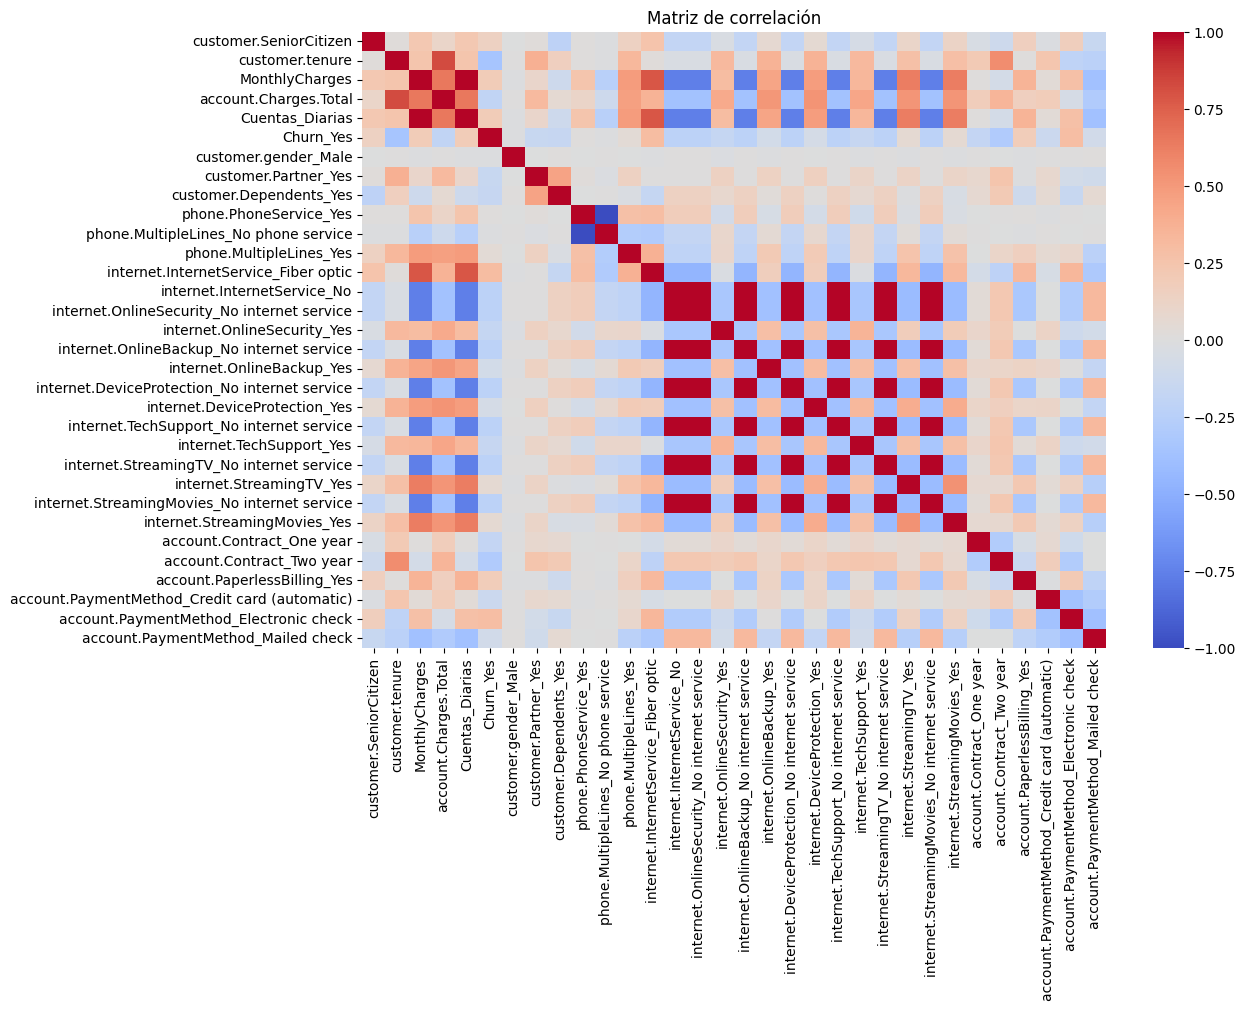

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

# Análisis Dirigido

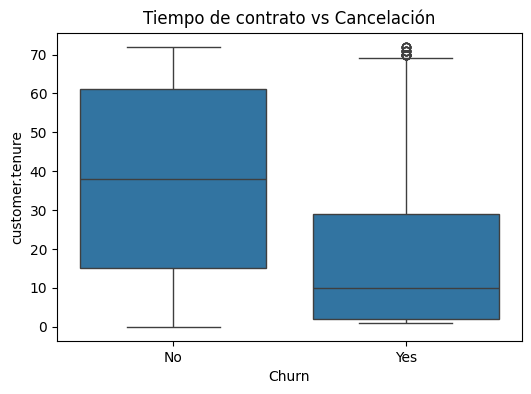

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="customer.tenure", data=df)
plt.title("Tiempo de contrato vs Cancelación")
plt.show()

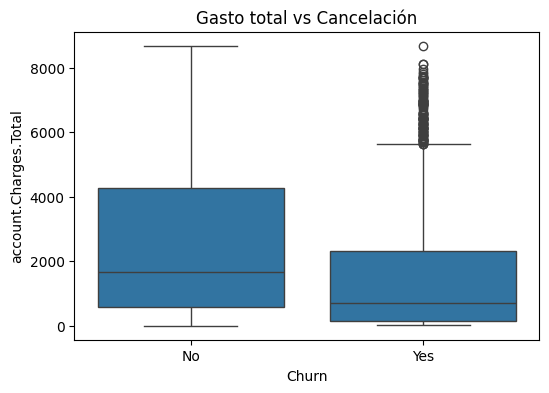

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="account.Charges.Total", data=df)
plt.title("Gasto total vs Cancelación")
plt.show()

# **🤖 Modelado Predictivo**

# Separación de Datos

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (5086, 31)
Prueba: (2181, 31)


# Creación de Modelos

In [21]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)

modelo_logistico.fit(X_train_scaled, y_train_bal)

y_pred_log = modelo_logistico.predict(X_test_scaled)

In [22]:
from sklearn.tree import DecisionTreeClassifier

modelo_arbol = DecisionTreeClassifier(random_state=42)

modelo_arbol.fit(X_train_bal, y_train_bal)

y_pred_arbol = modelo_arbol.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_log))
print("Accuracy Árbol de Decisión:", accuracy_score(y_test, y_pred_arbol))

Accuracy Regresión Logística: 0.7922971114167813
Accuracy Árbol de Decisión: 0.7427785419532325


# Evaluación de los Modelos

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("=== Regresión Logística ===")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_log))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_log))

=== Regresión Logística ===
Accuracy: 0.7922971114167813
Precision: 0.564437194127243
Recall: 0.650375939849624
F1-score: 0.6043668122270742

Matriz de confusión:
[[1382  267]
 [ 186  346]]

Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.88      0.84      0.86      1649
        True       0.56      0.65      0.60       532

    accuracy                           0.79      2181
   macro avg       0.72      0.74      0.73      2181
weighted avg       0.80      0.79      0.80      2181



In [26]:
print("=== Árbol de Decisión ===")

print("Accuracy:", accuracy_score(y_test, y_pred_arbol))
print("Precision:", precision_score(y_test, y_pred_arbol))
print("Recall:", recall_score(y_test, y_pred_arbol))
print("F1-score:", f1_score(y_test, y_pred_arbol))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_arbol))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_arbol))

=== Árbol de Decisión ===
Accuracy: 0.7427785419532325
Precision: 0.47571189279731996
Recall: 0.5338345864661654
F1-score: 0.5031000885739593

Matriz de confusión:
[[1336  313]
 [ 248  284]]

Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.84      0.81      0.83      1649
        True       0.48      0.53      0.50       532

    accuracy                           0.74      2181
   macro avg       0.66      0.67      0.66      2181
weighted avg       0.75      0.74      0.75      2181



1. Desempeño de los modelos
Al comparar los resultados obtenidos, se observa que la Regresión Logística presentó un desempeño más equilibrado en términos de precisión, recall y F1-score. Esto indica una mejor capacidad para identificar correctamente a los clientes que cancelan el servicio sin generar demasiados errores en las predicciones.

2. Comparación entre modelos
El Árbol de Decisión también logró realizar predicciones correctas, pero puede presentar mayor variabilidad en sus resultados. Este tipo de modelo tiende a ajustarse con mayor facilidad a los datos de entrenamiento, lo que puede afectar su capacidad de generalización.

3. Posible overfitting
El Árbol de Decisión puede presentar overfitting, ya que puede aprender patrones demasiado específicos de los datos de entrenamiento. Esto ocurre cuando el árbol crece demasiado y se vuelve muy complejo. Para evitarlo, se pueden ajustar parámetros como la profundidad máxima del árbol (max_depth) o el número mínimo de muestras por nodo.

4. Posible underfitting
Si el modelo fuera demasiado simple o no captara correctamente los patrones del dataset, podría producirse underfitting. En ese caso, sería necesario aumentar la complejidad del modelo o ajustar sus parámetros para mejorar su capacidad de aprendizaje.

5. Conclusión
En general, la Regresión Logística mostró un mejor equilibrio entre capacidad predictiva y generalización, mientras que el Árbol de Decisión puede requerir ajustes para evitar el sobreajuste. Por esta razón, la Regresión Logística puede considerarse un modelo adecuado para la predicción de cancelación de clientes en este análisis.

# **📋 Interpretación y Conclusiones**

# Análisis de la Importancia de las Variables


Variables más relevantes de la Regresión Logística

In [27]:
coef_log = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_logistico.coef_[0]
})

coef_log["Valor absoluto"] = coef_log["Coeficiente"].abs()
coef_log = coef_log.sort_values(by="Valor absoluto", ascending=False)

coef_log.head(10)

,Variable,Coeficiente,Valor absoluto
4,Cuentas_Diarias,-4.527849,4.527849
2,MonthlyCharges,-4.527849,4.527849
11,internet.InternetService_Fiber optic,4.253751,4.253751
8,phone.PhoneService_Yes,3.039774,3.039774
1,customer.tenure,-2.357597,2.357597
24,internet.StreamingMovies_Yes,1.647697,1.647697
9,phone.MultipleLines_No phone service,1.623825,1.623825
22,internet.StreamingTV_Yes,1.583513,1.583513
3,account.Charges.Total,1.523757,1.523757
10,phone.MultipleLines_Yes,0.938658,0.938658


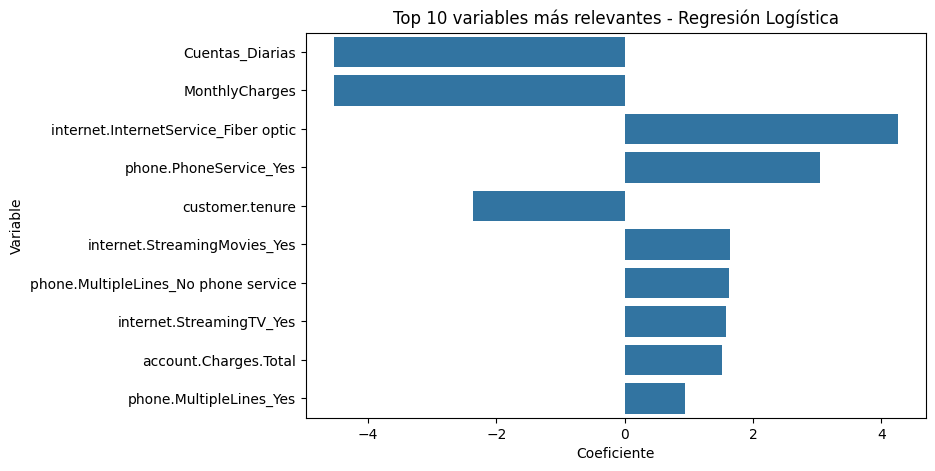

In [29]:
top_log = coef_log.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top_log, x="Coeficiente", y="Variable")
plt.title("Top 10 variables más relevantes - Regresión Logística")
plt.show()

Variables más relevantes del Árbol de Decisión

In [28]:
imp_arbol = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_arbol.feature_importances_
})

imp_arbol = imp_arbol.sort_values(by="Importancia", ascending=False)

imp_arbol.head(10)

,Variable,Importancia
29,account.PaymentMethod_Electronic check,0.214696
1,customer.tenure,0.162940
3,account.Charges.Total,0.140080
4,Cuentas_Diarias,0.086976
2,MonthlyCharges,0.079042
11,internet.InternetService_Fiber optic,0.056616
27,account.PaperlessBilling_Yes,0.044898
5,customer.gender_Male,0.018474
16,internet.OnlineBackup_Yes,0.017150
24,internet.StreamingMovies_Yes,0.016322


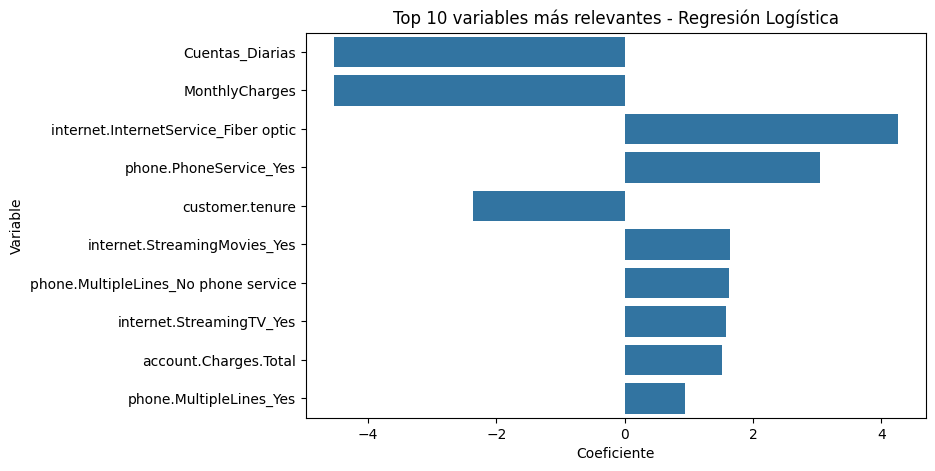

In [30]:
top_log = coef_log.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top_log, x="Coeficiente", y="Variable")
plt.title("Top 10 variables más relevantes - Regresión Logística")
plt.show()

Análisis de variables relevantes

1. Regresión Logística
Los coeficientes permiten identificar qué variables aumentan o reducen la probabilidad de cancelación. Las variables con coeficientes positivos favorecen el churn, mientras que las negativas se asocian con una menor probabilidad de cancelación.

2. Árbol de Decisión
La importancia de variables muestra cuáles aportan más información para separar clientes que cancelan de los que permanecen activos. Las variables con mayor importancia son las que más influyen en la clasificación.

3. Conclusión
En general, variables como el tiempo de permanencia del cliente, los cargos mensuales y el tipo de contrato suelen ser determinantes en la predicción de la cancelación del servicio.

# **Conclusión**

## Informe de análisis de cancelación de clientes

### 1. Factores que influyen en la cancelación

A partir del análisis de los datos y los modelos predictivos desarrollados, se identificaron varios factores relevantes asociados con la cancelación de clientes.

**Tiempo de permanencia (tenure)**  
Los clientes con menor tiempo en la empresa presentan una mayor probabilidad de cancelar el servicio.

**Cargos mensuales (MonthlyCharges)**  
Los clientes con cargos mensuales más elevados tienden a presentar mayores niveles de cancelación.

**Tipo de contrato**  
Los contratos de mayor duración, como los de uno o dos años, están asociados con una menor probabilidad de cancelación.

### 2. Comparación de modelos

Se desarrollaron dos modelos predictivos: Regresión Logística y Árbol de Decisión.

La **Regresión Logística** mostró un desempeño equilibrado en métricas como precisión, recall y F1-score.  
El **Árbol de Decisión** también identificó patrones relevantes, aunque puede presentar mayor riesgo de overfitting si no se controla su complejidad.

### 3. Estrategias de retención

A partir de los resultados obtenidos se proponen las siguientes estrategias:

- Implementar programas de fidelización para clientes nuevos.
- Promover contratos de mayor duración mediante incentivos.
- Revisar los planes con cargos mensuales elevados.
- Mejorar la calidad del servicio y el soporte al cliente.

### 4. Conclusión

El análisis permitió identificar los factores clave asociados con la cancelación de clientes. Los modelos predictivos desarrollados pueden servir como una herramienta para anticipar el churn y apoyar estrategias de retención que ayuden a reducir la pérdida de clientes.